In [70]:
import zarr
import xarray as xr
import numpy as np
import pandas as pd

from scipy import stats
from scipy.stats import linregress
from scipy.optimize import curve_fit
from statsmodels.stats.outliers_influence import variance_inflation_factor

import matplotlib.pyplot as plt
import shutil
import os
import warnings
import seaborn as sns

from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings('ignore', module='zarr')

In [71]:

def get_store(shot_id):
    """This function retrieves the date for a given shot ID from
    the MAST S3 bucket and returns a Zarr store object.
    
    Parameters:
    shot_id (int): The ID of the shot to retrieve data for.
    
    Returns:
    store: A Zarr store object containing the data for the 
    specified shot.
    """

    endpoint_url = 'https://s3.echo.stfc.ac.uk'
    url = f's3://mast/level2/shots/{shot_id}.zarr'

    # Get a handle to the remote file
    store = zarr.storage.FsspecStore.from_url(
        url,
        storage_options=dict(
            protocol='simplecache',
            target_protocol="s3",
            cache_storage='.cache', # stores the cached data locally
            target_options=dict(
                anon=True, # anonymous connection to S3
                endpoint_url=endpoint_url, 
                asynchronous=True) # doesn't stop notebook
        )
    )
    return store


In [72]:

def get_shot_average(store, group, variable, NBI_mask=True):
    """This function gets the average of a given parameter and its
    trimmed profile. It trims the profile by using a mask made from 
    the power_NBI during the NBI steady-state and interpolating it 
    to the corresponding group's time coordinate. It then interpolates
    the variables time coordinate to the common time, which has been 
    chosen to be the summary group's time coordinate.
    
    Parameters:
    xr.Dataset (store): dataset of all the parameters of this shot
    group: the group name corresponding to the variable
    variable: the parameter that will be trimmed and return an average
    NBI_mask (default=True): if True, will make parameter use NBI mask
    
    Returns:
    dict (average): average value of the variable
    dict (profile): trimmed profile of the variable"""


    try:
        data = xr.open_zarr(store, group=group)
        summary = xr.open_zarr(store, group='summary')

        common_time = summary['time']
        
        if NBI_mask:

            nbi_mask = summary.power_nbi > 1e5

            # additional stability mask — only keep times within 40% of median NBI power
            median_power = summary['power_nbi'].where(nbi_mask).median()
            stable_mask = np.abs(summary['power_nbi'] - median_power) / median_power < 0.3
            
            # combine both masks
            combined_mask = nbi_mask & stable_mask

            # interpolate combined mask to variable's time coordinate
            nbi_interp = combined_mask.astype(int).interp(
                time=data.time.astype(float), method='nearest').astype(bool)
            
            valid_time = data.time.where(nbi_interp, drop=True)
            length = len(valid_time)
            
            # trim first and last 10%
            trimmed_time = valid_time[int(0.1 * length) : int(0.9 * length)]
            variable_masked = data[variable].sel(time=trimmed_time)
            
            # if it has time dimensions, interpolates variable time to common time
            if 'time' in variable_masked.dims:
                variable_masked = variable_masked.interp(
                    time=common_time, method='linear')
                
        else:
            # does nothing with the variable
            variable_masked = data[variable]

            # for variables without time coordinate
            if 'time' not in variable_masked.dims:
                return {f'{variable}_average': variable_masked.values}
            
            # interpolates to common time
            variable_masked = variable_masked.interp(time=common_time, method='linear')
            
        # if variable is Nan
        if variable_masked.isnull().all():
            return None

        # if result is scalar, convert to float
        # if result is array (2D variable), keep as array
        averaged = variable_masked.mean(dim='time')
        average_val = float(averaged) if averaged.ndim == 0 else averaged

        # returns average
        return {f'{variable}_average': average_val}

    except Exception as e:
        return None

In [73]:

def get_parameters(shot_min, shot_max):
    """This function gets all the parameters needed for
    this project, and returns the average values of a shot's
    parameters and the trimmed profiles. It will then do this 
    over the specified range of shots.
    
    Parameters:
    shot_min: the minimum shot_id
    shot_max: the maximum shot_id
    
    Returns:
    pd.DataFrame: dataframe of the parameters' averages over
    every shot
    xr.Dataset: dataset of the parameters' trimmed profile
    over every shot"""

    # list to contain data over all shots
    total_results_average = []

    # create folders if they don't exist for average and dataframe to be in
    os.makedirs('mast_averages', exist_ok=True)

    csv_path  = f'mast_averages/mast_parameters_{shot_min}_{shot_max}.csv'

    for shot_id in range(shot_min, shot_max + 1):
        try:
            
            # dict to contain data over one shot
            results_average = {}
            
            store = get_store(shot_id)

            # 1D scalar parameters - go into average dataframe
            scalar_parameters = {
            'n_e_core':        ('thomson_scattering', 'n_e_core'),
            't_e_core':        ('thomson_scattering', 't_e_core'),
            'ip':              ('summary', 'ip'),
            'vloop':           ('equilibrium', 'vloop_static'),
            'power_nbi':       ('summary', 'power_nbi'),
            'power_radiated':  ('summary', 'power_radiated'),  # add this
            'n_e_line':        ('interferometer', 'n_e_line'),
            'wmhd':            ('equilibrium', 'wmhd'),
            'b_strength':      ('equilibrium', 'bvac_rmag'),
            'major_radius':    ('equilibrium', 'magnetic_axis_r'),
            'minor_radius':    ('equilibrium', 'minor_radius'),
            'elong':           ('equilibrium', 'elongation'),
            }


            # gets the average of each parameter
            for key, (group, val) in scalar_parameters.items():
                
                val_average = get_shot_average(store, group, val)
                 
                results_average[key] = list(val_average.values())[0] if val_average is not None else None

           
            # if all required data is present
            required = ['ip', 'power_nbi', 'wmhd', 'n_e_core', 't_e_core', 'power_radiated', 'vloop']

            required_present = all(results_average.get(k) is not None for k in required)

            if required_present:
                
                # tells us a shot succeeded
                print(f"Shot {shot_id} succeeded")
                
                # adds to main average list
                results_average['shot_id'] = shot_id
                results_average['mass'] = 2

                # calculates some extra parameters
                results_average['power_ohmic'] = results_average['vloop'] * results_average['ip']
                results_average['power_total'] = (results_average['power_nbi'] 
                                                  + results_average['power_ohmic'] 
                                                  - results_average['power_radiated'])

                total_results_average.append(results_average)
                
            
            # if data is missing in shot from required list, will say in console
            else:
                print(f'Shot {shot_id} failed: missing data')

        # if it fails to get parameters of a shot            
        except Exception as e:
            print(f"Shot {shot_id} failed: {e}")
            continue

    # adds average to pandas dataframe 
    average_df = pd.DataFrame(total_results_average)
    average_df.to_csv(csv_path, index=False)

    return average_df


In [74]:

def get_average_from_file(shot_min, shot_max):
    """This function checks if a file exists and then
    reads from it, otherwise it gets the data from the 
    mast s3 bucket
    
    Parameters:
    shot_min: the minimum shot_id
    shot_max: the maximum shot_id
    
    Returns:
    pd.DataFrame: dataframe of the parameters' averages over
    every shot"""

    csv_path  = f'mast_averages/mast_parameters_{shot_min}_{shot_max}.csv'
    
    # checks if the files have been made yet
    if os.path.exists(csv_path):
        try:
            average_df = pd.read_csv(csv_path)
            return average_df
        except Exception as e:
            print(f"Could not read cached files: {e}")

    # fetch from S3
    average_df = get_parameters(shot_min, shot_max)

    if average_df is None or average_df.empty:
        print("No averages in dataframe")
        average_df = pd.DataFrame()
    
    return average_df

In [75]:
shot_min = 30470
shot_max = 30470

average_df = get_average_from_file(shot_min, shot_max)

# check which columns contain non-scalar values
for col in average_df.columns:
    val = average_df[col].iloc[0]
    print(f"{col}: {type(val).__name__} = {val if not hasattr(val, 'shape') else val.shape}")



n_e_core: float64 = ()
t_e_core: float64 = ()
ip: float64 = ()
vloop: float64 = ()
power_nbi: float64 = ()
power_radiated: float64 = ()
n_e_line: float64 = ()
wmhd: float64 = ()
b_strength: float64 = ()
major_radius: float64 = ()
minor_radius: float64 = ()
elong: float64 = ()
shot_id: int64 = ()
mass: int64 = ()
tau_e: float64 = ()
power_ohmic: float64 = ()
power_total: float64 = ()


The Power NBI has been sliced such that it must reach a threshold of 1e5, and only data points that are within 30% of the median are considered. Each point was then interpolated to this time frame and trimmed. This is to ensure the averages found are only when the reactor is in steady-state, allowing us to show clean plots.

In [76]:
def calculate_tau_e(average_df):
    """Calculates the ITER-89P confinement
    time using the parameters from the average
    dataframe
    
    Returns:
    tau_e: array of tau_e calculated values"""

    shot_min = 29000
    shot_max = 30500

    if not average_df.size == 0:

        required_cols = ['ip', 'major_radius', 'minor_radius', 'elong', 
                        'n_e_line', 'b_strength', 'power_total']

        df_iter = average_df[required_cols].dropna()

        ip = df_iter['ip'] / 1e6
        R = df_iter['major_radius']
        a = df_iter['minor_radius']
        elong = df_iter['elong']
        n_e_line = df_iter['n_e_line'] / 1e20
        B = df_iter['b_strength'].abs()
        P = df_iter['power_total'].abs() / 1e6
        M = 2

        tau_e = 0.048 * ip**0.85 * R**1.2 * a**0.3 \
                    * elong**0.5 * n_e_line**0.1 \
                    * B**0.2 * M**0.5 * P **-0.5
        
        return tau_e
    else:
        tau_e = None
        return tau_e 

In [77]:
def scatter_parameters(x, y, xlabel=None, ylabel=None, title=None):
    """This function plots a given variable against another
    as well as performs a linear regression to ouput a gradient,
    intercept and r-value.
    
    Parameters:
    x: parameter to be plotted on x-axis
    y: parameter to be plotted on y-axis
    xlabel (default=None): label for the x-axis
    ylabel (default=None): label for the y-axis
    title (default=None): title of the plot"""


    fig, axes = plt.subplots()
    fig.set_size_inches(7, 5)

    axes.scatter(x, y, alpha=0.7)

    axes.set_xlabel(xlabel)
    axes.set_ylabel(ylabel)
    axes.set_title(title)

    gradient, intercept, r_value, p_value, std_err = linregress(x, y)
    x_line = np.linspace(x.min(), x.max(), 100)

    axes.plot(x_line, gradient * x_line + intercept, 'r--', label=f'Linear fit (R²={r_value**2:.2f})')
    axes.legend()

    print(f'm: {gradient}')
    print(f'c: {intercept}')

    return axes

    plt.tight_layout()
    plt.show()

m: 0.06421276101443549
c: 0.005382055352286384


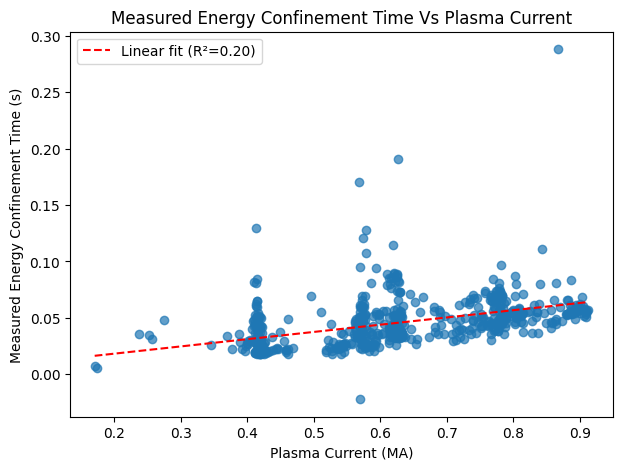

In [78]:
shot_min = 29000
shot_max = 30500

average_df = get_average_from_file(shot_min, shot_max)
clean_df = average_df.dropna()

ip_average = clean_df['ip'] / 1e6 # A -> MA
measured_tau_e = clean_df['wmhd'] / clean_df['power_total']

if not clean_df.size == 0:
    scatter_parameters(ip_average, 
                       measured_tau_e, 
                       xlabel="Plasma Current (MA)",
                       ylabel="Measured Energy Confinement Time (s)",
                       title="Measured Energy Confinement Time Vs Plasma Current")

This compares the measured energy confinement time, to the plasma current. A positive correlation can be seen, which is to be expected, as higher plasma current generally produces better confinement, meaning longer confinement time.

m: 0.027488972780482707
c: 0.007613727294205223

H factor
count    645.000000
mean       1.753428
std        0.420377
min       -1.480293
25%        1.475756
50%        1.732967
75%        1.921581
max        4.071709
Name: H_factor, dtype: float64


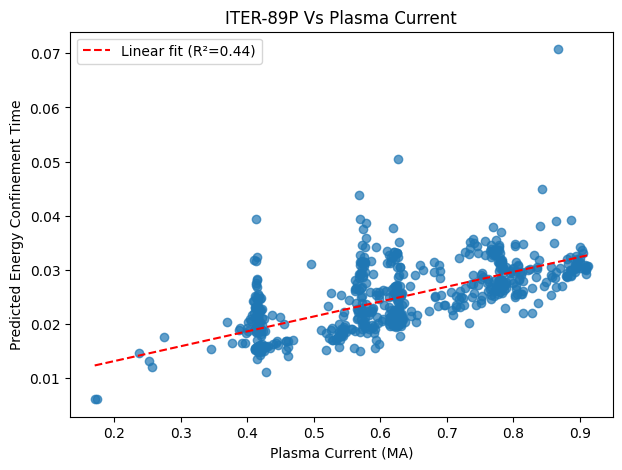

In [79]:
shot_min = 29000
shot_max = 30500


average_df = get_average_from_file(shot_min, shot_max)
clean_df = average_df.dropna()

predicted_tau_e = calculate_tau_e(clean_df)
ip = clean_df['ip'] / 1e6
measured_tau_e = clean_df['wmhd'] / clean_df['power_total']

if not clean_df.size == 0:
    
    scatter_parameters(ip, predicted_tau_e, 
                       xlabel="Plasma Current (MA)",
                       ylabel="Predicted Energy Confinement Time",
                       title="ITER-89P Vs Plasma Current")
    
    clean_df['H_factor'] = measured_tau_e / predicted_tau_e
    print("\nH factor")
    print(clean_df['H_factor'].describe())


This shows  a plot of how the ITER-89P scaling law increases with the plasma current. The high $r^2$ shows that there is a strong correlation. We also see we have an avergae H factor of 1.75, which is reasonable for MAST. This means that MAST's confinement was 1.75 times better than what ITER-89P predicts.

m: 3.1472159184813857
c: -0.0322853589310099


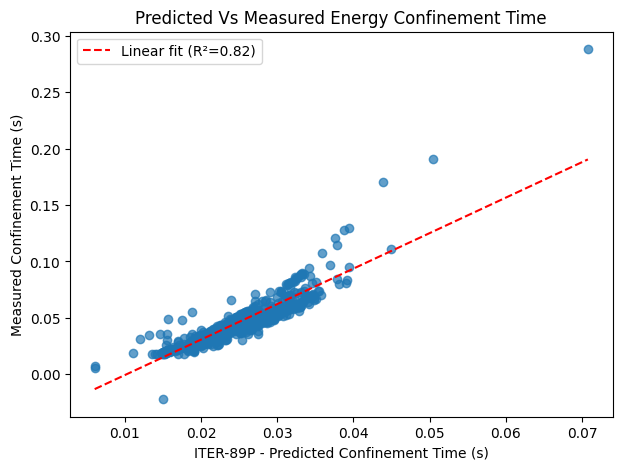

In [80]:
shot_min = 29000
shot_max = 30500

average_df = get_average_from_file(shot_min, shot_max)
clean_df = average_df.dropna()

iter_89p = calculate_tau_e(clean_df)
measured_tau_e = clean_df['wmhd'] / clean_df['power_total']

if not clean_df.size == 0:
    scatter_parameters(iter_89p,
                       measured_tau_e,
                       xlabel="ITER-89P - Predicted Confinement Time (s)",
                       ylabel="Measured Confinement Time (s)",
                       title="Predicted Vs Measured Energy Confinement Time")


Comparing the energy confinment time predicted by the ITER-89P scaling law using  the function calculate_tau_e(), and the measured energy confinment time calculated using WMHD / power_total. A linear equation of $x = y$ can be seen, which shows that the emprical formula is correct in predicting the confinment time. Outliers may be caused due to spikes in confinement, or entering high mode plasma confinment.

ip: 0.012273
n_e_core: 0.001849
t_e_core: -0.003839
b_strength: -0.003940
elong: -0.003226
minor_radius: 0.001877
r2: 0.37197513322002884

        feature       VIF
0            ip  5.260491
1      n_e_core  1.183994
2      t_e_core  3.056821
3    b_strength  1.200675
4         elong  2.661538
5  minor_radius  1.595484


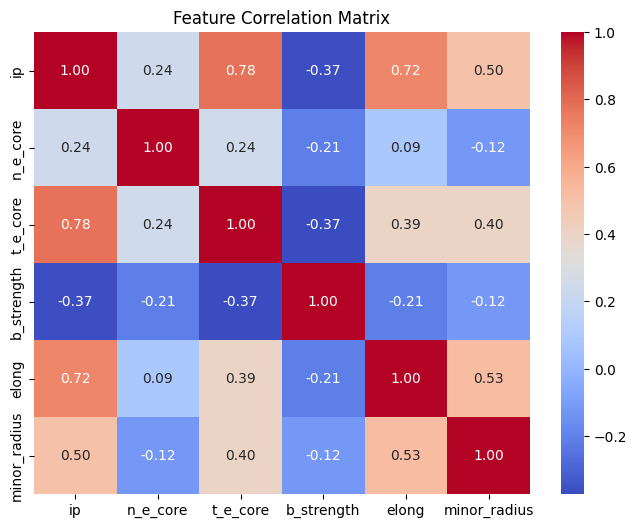

In [81]:
shot_min = 29000
shot_max = 30500

# removes any NaNs from dataframe
average_df = get_average_from_file(shot_min, shot_max)
clean_df = average_df.dropna()
clean_df['measured_tau_e'] = clean_df['wmhd'] / clean_df['power_total'] 

features = ['ip', 'n_e_core', 't_e_core', 'b_strength', 'elong', 'minor_radius']
target = 'measured_tau_e' 

# removes outliers
clean_df = clean_df[np.abs(stats.zscore(clean_df[target])) < 3]

X = clean_df[features]
y = clean_df[target]

scaler = StandardScaler()

# transforms the data such that each feature has equal weight
# and reasonable coefficients
fitted_data = scaler.fit_transform(X)

X_scaled = pd.DataFrame(fitted_data, columns=features)

# performs the linear regression
model = LinearRegression()
model.fit(X_scaled, y)

# measures how well regression coefficients predict y
y_predicted = model.predict(X_scaled)
r2 = r2_score(y, y_predicted)

# shows coefficient for each feature
for feature, coef in zip(features, model.coef_):
    print(f"{feature}: {coef:.6f}")

print(f'r2: {r2}\n')

# gives the vif, which lets us see how distorted the coefficients' variances are
vif = pd.DataFrame()
vif['feature'] = features
vif['VIF'] = [variance_inflation_factor(X_scaled.values, i) for i in range(X_scaled.shape[1])]
print(vif)

fig, ax = plt.subplots(figsize=(8, 6))

sns.heatmap(clean_df[features].corr(), 
            annot=True, 
            fmt='.2f', 
            cmap='coolwarm',
            ax=ax)

plt.title('Feature Correlation Matrix')
plt.show()


Multi-parameter linear regression of τ_E against plasma parameters yields some counterintuitive coefficients, for example, b_strength shows a negative coefficient despite magnetic field strength being expected to improve confinement. This is likely a consequence of multicollinearity. Several features are correlated with each other, as shown in the correlation matrix above, causing the model to distort the coefficients in unintuitive ways.

Variance Inflation Factor (VIF) analysis also shows this. Plasma current, with VIF=5.4, shows the strongest inflation, consistent with its high correlation with t_e_core, $r=0.78$, and elongation, $r=0.72$.

Random Forest R² = 0.690
ip: 0.2964
n_e_core: 0.1129
t_e_core: 0.0782
b_strength: 0.2955
elong: 0.1008
minor_radius: 0.1161


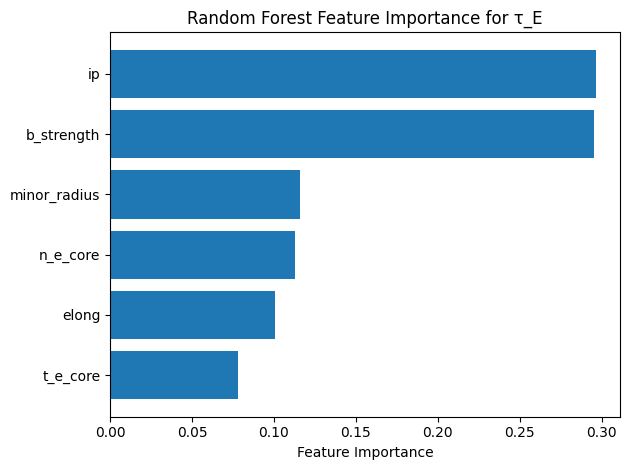

In [82]:
shot_min = 29000
shot_max = 30500

# removes any NaNs from dataframe
average_df = get_average_from_file(shot_min, shot_max)

# cleans dataframe such that NaNs are removed
clean_df = average_df.dropna()

# makes measured tau_e column
clean_df['measured_tau_e'] = clean_df['wmhd'] / clean_df['power_total'] 

# assigns parameters to be used to predict target parameter
features = ['ip', 'n_e_core', 't_e_core', 'b_strength', 'elong', 'minor_radius']
target = 'measured_tau_e'

# cleans dataframe such that outliers are removed
clean_df = clean_df[np.abs(stats.zscore(clean_df[target])) < 3]

# separates data between used parameters and target
X = clean_df[features]
y = clean_df[target]

scaler = StandardScaler()

# scales parameters such that the increase in each one has the same weight
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=features)

# train test split, splits data for training, and testing,
# evaluates how needed each parameter is for prediciton 
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=43)

# prodcues 100 decision trees with fixed random state for reproducibility
model_rf = RandomForestRegressor(n_estimators=100, random_state=42)
model_rf.fit(X_train, y_train)

r2_rf = r2_score(y_test, model_rf.predict(X_test))
print(f"Random Forest R² = {r2_rf:.3f}")

for feature, importance in zip(features, model_rf.feature_importances_):
    print(f"{feature}: {importance:.4f}")

importances = model_rf.feature_importances_
sorted_idx = np.argsort(importances)

# produces horzintal barchart of feature importances
plt.barh([features[i] for i in sorted_idx], importances[sorted_idx])
plt.xlabel('Feature Importance')
plt.title('Random Forest Feature Importance for τ_E')
plt.tight_layout()
plt.show()

This shows how important each parameter is in reducing the prediction error. In the random forest regressor, 100 descision trees are produced, and a subset of random samples from the dataframe is selected for each tree, while also choosing a random subset of features to be assigned to each tree. At each decision tree, it will try to minimise the prediction error given its features. When running the testing, each test point runs through the 100 trees, and averages their predictions. Each features' weight in prediction error is called its importance, which has been shown in the bar chart above.

Random forest regression mitigates the effects of multicollinearity when it comes to its predictive power, as it does not attempt to assign any coefficients to the features, but only uses whatever features minimise prediction error the most. It can still lead to bias in the feature importance, which is why this bar chart is not a good metric. Instead its $r^2 = 0.690$ should be looked at, which compared to the linear regression's $r^2 = 0.372$ , is much better.

m: 0.657497451518118
c: 0.014962748417679219


C:\Users\james\AppData\Local\Temp\ipykernel_5316\1806630754.py:12: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "g-" (-> color='g'). The keyword argument will take precedence.
  axes.plot([0, max_val], [0, max_val], 'g-', label='Perfect prediction (y=x)', color='orange')


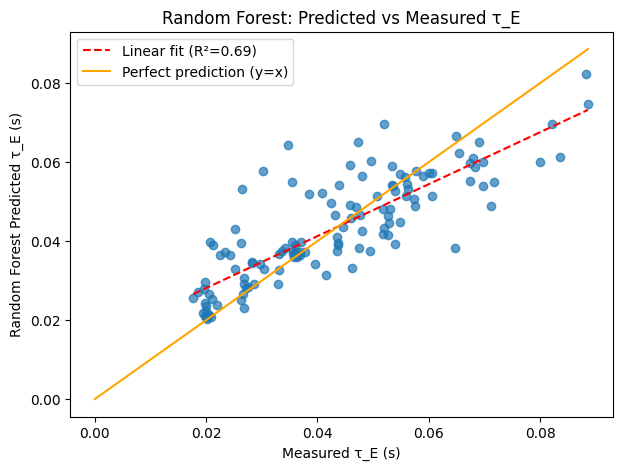


H factor
count    108.000000
mean       0.991686
std        0.208437
min        0.496904
25%        0.892297
50%        0.994298
75%        1.115994
max        1.687486
Name: H_factor, dtype: float64


In [86]:
y_pred = model_rf.predict(X_test)

# plots models predicted estimates for tau_e against measured valeus
axes = scatter_parameters(pd.Series(y_test.values), 
                   pd.Series(y_pred),
                   xlabel='Measured τ_E (s)',
                   ylabel='Random Forest Predicted τ_E (s)',
                   title='Random Forest: Predicted vs Measured τ_E')

#plots a y=x plot for reference 
max_val = max(pd.Series(y_test.values).max(), pd.Series(y_pred).max())
axes.plot([0, max_val], [0, max_val], 'g-', label='Perfect prediction (y=x)', color='orange')

plt.legend()
plt.show()

# displays data on the predicted H factors
clean_df['H_factor'] = pd.Series(y_test.values) / pd.Series(y_pred)
print("\nH factor")
print(clean_df['H_factor'].describe())

Plot above compares the measured tau_e against the random forest model's predictions. ITER-89P has $r^2 = 0.82$, therefore does outperform the model's $r^2 = 0.69$. We also see there's a large difference in the H factor calculated, showing the model predicts the confinement of MAST to be much worse.

In [84]:
def log_power_law(log_n_e, log_A, alpha):
    """This function is used for finding the fit
    for the n_e and t_e data. It uses logs, which is
    more stable.
    
    Parameters:
    log_n_e: the electron density
    log_A: the predicted coefficient
    alpha: the predicted power
    
    Returns:
    The predicted electron temperature"""

    return log_A + alpha * log_n_e

def fit_n_t_e(clean_df):
    """This function performs a curve fit for the 
    n_e and t_e data. It then prints this information 
    to the console. It also does a separate chi-squared
    calculation, which is used to find the reduced chi-squared
    using the fitted results, and prints this to console.
    
    Parameters:
    pd.DataFrame: the dataframe where n_e and t_e will be accessed

    Returns:
    A_fit: the predicted coefficient
    alpha_fit: the predicted power"""

    if not clean_df.size == 0:

        n_e_core = clean_df['n_e_core']
        t_e_core = clean_df['t_e_core']

        # fits data
        popt, pcov = curve_fit(log_power_law,
                            np.log(n_e_core.values),
                            np.log(t_e_core.values),
                            p0=[1, 0.5])

        # fit values
        log_A_fit, alpha_fit = popt
        A_fit = np.exp(log_A_fit)

        print(f"A = {A_fit:.3e}")

        # uses the covariance matrix to find the uncertainty
        perr = np.sqrt(np.diag(pcov))
        print(f"α = {alpha_fit:.3f} ± {perr[1]:.3f}")

        # predict in log space
        log_t_e_predicted = log_power_law(np.log(n_e_core.values), log_A_fit, alpha_fit)

        # convert back to linear space
        t_e_predicted = np.exp(log_t_e_predicted)

        # perfroms chi-squared with fitted data
        residuals = t_e_core.values - t_e_predicted
        sigma = t_e_core.std()

        # gives the reduced chi-squared
        chi2_reduced = np.sum((residuals/sigma)**2) / (len(residuals) - 2)
        print(f"Reduced χ² = {chi2_reduced:.3f}")

        return A_fit, alpha_fit

A = 2.310e-04
α = 0.337 ± 0.044
Reduced χ² = 0.945


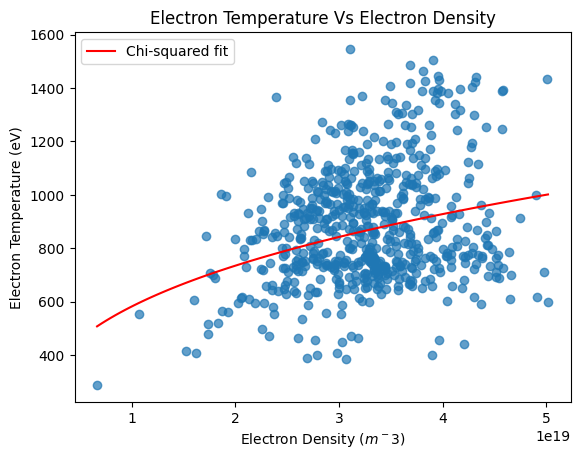

In [85]:
shot_min = 29000
shot_max = 30500

average_df = get_average_from_file(shot_min, shot_max)
clean_df = average_df.dropna()

if not clean_df.size == 0:
    
    # gathers necessary parameters
    t_e_core = clean_df['t_e_core']
    n_e_core = clean_df['n_e_core']
    A, alpha = fit_n_t_e(clean_df)
    x = np.linspace(clean_df['n_e_core'].min(), clean_df['n_e_core'].max(), 100)

    fig, axes = plt.subplots()

    # plots the data
    axes.scatter(n_e_core, t_e_core, alpha=0.7)

    # plots the fit
    axes.plot(x, A*x**alpha, label="Chi-squared fit", color="red")

    axes.set_xlabel("Electron Density ($m^-3$)")
    axes.set_ylabel("Electron Temperature (eV)")
    axes.set_title("Electron Temperature Vs Electron Density")
    axes.legend()

    plt.show()

The plot shows a chi-squared fit overlaid the electron temperature against electron density, giving the fit: $t_e = 2.31 * n_e^{(0.337 +- 0.044)} * 10^{-4}$. It has a reduced chi-squared of 0.945, indicating that it is a good statistical fit for the data.